# Natural Language Processing. Assignment 1. Tokenization.

In this assignment, you need to implement, train, and analyze a Byte-Pair Encoding (BPE) tokenizer.

The assignment consist of 3 tasks. When you finish all the tasks, create a GitHub repository for this assignment (you can use this repository later for the other assignments) and submit this notebook in the repository. Leave `requirements.txt` file if your code requires additional installations. Submit the link to the repository in Moodle.

## Task 1: Data Preparation and Vocabulary Size Selection (3 points)

First, load the [Brown corpus](https://en.wikipedia.org/wiki/Brown_Corpus). After loading the corpus, you need to select the appropriate vocabulary size for the BPE tokenizer. The appropriate vocabulary size is the minimal vocabulary size that covers at least 90% of the words in the corpus. The coverage is calculated according to the following formula:



$$ \text{coverage}(k) = \frac{\sum_{r=1}^{k} f(r)}{\sum_{r=1}^{N} f(r)} $$



where $f(r)$ is the frequency of the top-$r$ word, $k$ is the number of top-$k$ tokens included in vocab, $N$ is the total unique words in corpus.

So, for this task you need to do the following:

1. Load the Brown corpus (0.5 points)
2. Plot cumulative coverage vs. vocabulary size for the loaded corpus (1 point)
3. Select the appropriate vocabulary size (0.5 point)
4. Answer the questions:
    1. Why the coverage slows down the increase as the vocabulary size increases? (0.5 point)
    2. Which empirical law explains the slowing down increase of the coverage? (0.5 point)

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from collections import Counter
import pandas as pd
import numpy as np
from tqdm import tqdm

np.random.seed(52)

nltk.download('brown')
from nltk.corpus import brown

sns.set_palette(sns.color_palette('CMRmap'))

[nltk_data] Downloading package brown to /usr/share/nltk_data...
[nltk_data]   Package brown is already up-to-date!


In [2]:
def calc_coverage(k: int, cum_counter: list) -> float:
    numerator = cum_counter[k]
    denominator = cum_counter[-1]
    return numerator / denominator


# 1.1
brown_words = brown.words()
counter = Counter(brown_words)

# calculate the cumulative sum for faster calculation of the coverage
sorted_counter = sorted(counter.items(), key=lambda x: x[1], reverse=True)
cum_counter = [0]
for i in range(len(sorted_counter)):
    cum_counter.append(cum_counter[-1] + sorted_counter[i][1])

# prepare plot data
vocabulary_sizes = []
coverage = []
for k in range(len(counter)):
    vocabulary_sizes.append(k)
    coverage.append(calc_coverage(k, cum_counter))

df_cum_coverage = pd.DataFrame({
    'vocab_size': vocabulary_sizes,
    'cum_coverage': coverage
})


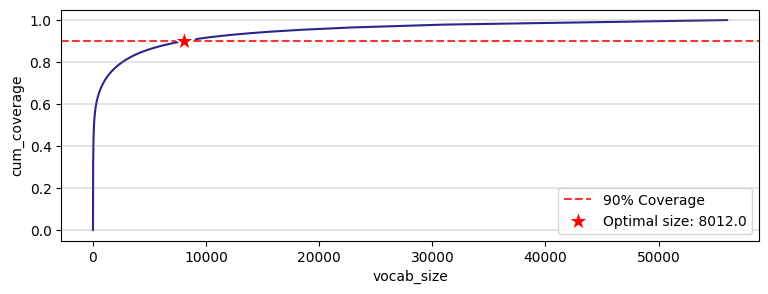

The optimal vocabulary size: 8012.0


In [3]:
# 1.2

fig, ax = plt.subplots(1, 1, figsize=(9, 3))
ax.grid(axis='y', color='grey', linewidth=0.3)

# horizontal line for required 90% coverage
ax.axhline(0.9,
           color='red',
           linestyle='--',
           label=f'90% Coverage',
           alpha=0.8,
           zorder=0)

# the required plot
sns.lineplot(data=df_cum_coverage,
             x='vocab_size',
             y='cum_coverage',
             ax=ax,
             zorder=1)

# optimal point (minimal vocabulary size that covers at least 90% of the words)
optimal_point = df_cum_coverage.query('cum_coverage >= 0.9').iloc[0]
sns.scatterplot(x=[optimal_point.vocab_size],
                y=[optimal_point.cum_coverage],
                color='red',
                marker='*',
                s=250,
                ax=ax,
                label=f'Optimal size: {optimal_point.vocab_size}',
                zorder=2)

ax.legend(loc='lower right')
plt.show()

# 1.3
print(f'The optimal vocabulary size: {optimal_point.vocab_size}')

### **1.4 Question Answering**

* The bottom of the words rank list consist of rare words with the smaller occurencies amount. Therefore, the cumulative sum of the occurencies starts to slow down and as it tends to the sum of the whole occurencies, the coverage slowly tends to its maximum (`i.e. 1`)

* **Zipf's law**: $f(r) \propto \frac{1}{r^\alpha}$. With higher rank comes lower frequency

## Task 2: Implement Byte-Pair Encoding (BPE) Tokenizer (4 points)

Implement the [BPE tokenizer](https://arxiv.org/pdf/1508.07909) as the `BPETokenizer` class.

The class should contain correctly implemented:

* `train` method (1.5 points).
* `tokenize` method (1.5 points).

The code should have docstrings and comments (1 point).

In [4]:
class BPETokenizer:
    """
    BPE tokenizer implementation

    The algorithm:
    1. Initialize the vocabulary with the unique characters in the corpus and add end-of-word token
    2. From the initial token list splitted by words and punctuation, obtain new token list represented by the characters and eow token
    3. Iteratively combine the two most frequent tokens and update the vocabulary until the required size is not reached
    4. Tokenize the new sentences after the training
    """

    def __init__(self, target_vocabulary_size: int, corpus: list,
                 eow_token: str):
        """
        Tokenizer initialization.

        Parameters:
        - target_vocabulary_size: the target amount of tokens
        - corpus: the list of words and punctuation marks
        - eow_token: addtional token defining the end of the word or punctuation mark
        """

        self.target_vocabulary_size = target_vocabulary_size
        self.corpus = corpus
        self.eow_token = eow_token

        # initialize the vocabulary with the symbols and eow-token
        self.vocabulary = self.__get_initial_vocabulary(self.corpus)

        # get tokens from the corpus based on the obtained vocabulary
        self.tokens = self.__get_tokens(self.corpus)

        # merged token list
        self.merges = []

    def __get_initial_vocabulary(self, corpus: list) -> set:
        """
        Collects the unique symbols of the corpus and adds eow-token

        Parameters:
        - corpus: the list of words and punctuation marks

        Returns:
        - set: the initial vocabulary
        """

        vocabulary = set(self.eow_token)
        for token in corpus:
            for char in token:
                vocabulary.add(char)
        return vocabulary

    def __get_tokens(self, corpus: list) -> list:
        """
        Translate the given corpus to the list of word characters

        Parameters:
        - corpus: the list of words and punctuation marks

        Returns:
        - list: the list of characters
        """

        tokens = list()
        for token in corpus:
            tokens.extend(list(token) + [self.eow_token])
        return tokens

    def __collect_stats(self, tokens: list) -> Counter:
        """
        Counts the amount of adjacent token pairs in a sequence

        Parameters:
        - tokens: the list of tokens (characters)

        Returns:
        - the Counter object with the calculated frequencies
        """

        pairs = Counter()
        for i in range(len(tokens) - 1):
            pairs[(tokens[i], tokens[i + 1])] += 1
        return pairs

    def train(self):
        """
        Trains BPE

        The algorithm:
        While the actual vocabulary size is less than the required:
        1. Count the frequencies of the adjacent tokens in the sequence
        2. Choose the most frequent pair
        3. Merge tokens, add new one to the dictionary and the merging list
        4. Update the sequence based on the new dictionary
        """

        initial_size = len(self.vocabulary)
        total_steps = self.target_vocabulary_size - initial_size
        pbar = tqdm(total=total_steps, desc='BPE training')

        while len(self.vocabulary) < self.target_vocabulary_size:
            pairs = self.__collect_stats(self.tokens)
            if not pairs:
                break

            # add the new token
            (t1, t2), _ = pairs.most_common(1)[0]
            new_token = t1 + t2
            self.vocabulary.add(new_token)
            self.merges.append((t1, t2))

            # update the sequence
            new_tokens = []
            i = 0
            while i < len(self.tokens):
                if i < len(self.tokens) - 1 and self.tokens[
                        i] == t1 and self.tokens[i + 1] == t2:
                    # add the new token if it is detected
                    new_tokens.append(new_token)
                    i += 2
                else:
                    # add the current token
                    new_tokens.append(self.tokens[i])
                    i += 1

            self.tokens = new_tokens
            pbar.update(1)

        pbar.close()

    def tokenize(self, document: str) -> list:
        """
        Tokenize the sequence based on the vocabulary

        Parameters:
        - document: the list of words and punctuation marks

        Returns:
        - list: the list of tokens
        """

        result = []
        for word in document:
            word_tokens = list(word) + [self.eow_token]
            for (a, b) in self.merges:
                new_word_tokens = []
                i = 0
                while i < len(word_tokens):
                    if i < len(word_tokens) - 1 and word_tokens[
                            i] == a and word_tokens[i + 1] == b:
                        # add the new token if it is detected
                        new_word_tokens.append(a + b)
                        i += 2
                    else:
                        # add the current token
                        new_word_tokens.append(word_tokens[i])
                        i += 1
                word_tokens = new_word_tokens

            result.extend(word_tokens)

        return result

## Task 3: Tokenizer Training and Analysis (3 points)

1. Train the `BPETokenizer` on the Brown corpus with the appropriate vocabulary size selected in Task 1 (1 points)
2. Use the Brown corpus (1000 samples) to calculate the mean and standard deviation of
    * tokenizer's fertility (1 points)
    * length of the tokenized sentence (1 points)

In [5]:
tokenizer = BPETokenizer(
    int(optimal_point.vocab_size),  # 8012
    brown_words,
    '</w>')

tokenizer.train()

print(f'The actual vocabulary size: {len(tokenizer.vocabulary)}')

BPE training: 100%|██████████| 7927/7927 [3:05:31<00:00,  1.40s/it]

The actual vocabulary size: 8012


In [6]:
brown_sentences = brown.sents()
sample_size = 1000

chosen_ind = np.random.choice(len(brown_sentences), size=sample_size, replace=False)
chosen_brown_sentences = [brown_sentences[i] for i in chosen_ind]

print(f'Tokenization example: {tokenizer.tokenize(brown_sentences[0])}')

fertilities = []
lengths = []

for sent_words in tqdm(brown_sentences, desc='Tokenizing samples'):
    num_words = len(sent_words)
    tokens = tokenizer.tokenize(sent_words)

    length = len(tokens)
    lengths.append(length)

    fertility = length / num_words
    fertilities.append(fertility)

mean_fertility = np.mean(fertilities)
std_fertility = np.std(fertilities)
mean_length = np.mean(lengths)
std_length = np.std(lengths)

print(f'Fertility: mean = {mean_fertility:.2f}, std = {std_fertility:.2f}')
print(f'Tokenized sentence length: mean = {mean_length:.2f}, std = {std_length:.2f}')

Tokenization example: ['The</w>', 'F', 'ul', 'ton</w>', 'County</w>', 'Gr', 'and</w>', 'J', 'ury</w>', 'said</w>', 'Friday</w>', 'an</w>', 'investig', 'ation</w>', 'of</w>', 'Atl', 'an', 'ta', "'s</w>", 'recent</w>', 'primary</w>', 'election</w>', 'produced</w>', '``</w>', 'no</w>', 'evidence</w>', "''</w>", 'that</w>', 'any</w>', 'ir', 'regul', 'ari', 'ties</w>', 'took</w>', 'place</w>', '.</w>']


Tokenizing samples: 100%|██████████| 57340/57340 [47:10<00:00, 20.26it/s]

Fertility: mean = 1.34, std = 0.27
Tokenized sentence length: mean = 27.00, std = 18.04


## Grading Procedure Details

During the grading of the completed assignments, a random set of students will be sampled for the **offline assignment defence**. The defence will be arranged shortly after the assignment submission deadline. The particular date and time will be announced later.

The aim of the assignment defence is to ensure the students understand well their own solutions and know how thier solution works. To check this, the students will be asked various questions about the provided solution. In addition, the students will be asked to run their solution to ensure the solution works without errors.

Examples of questions:

1. How the cumulative coverage is calculated? Why is it called cumulative?
2. What is the rank of a word?
3. How does the BPE tokenizer work? Note: for this question, the students will not be able to see the their own implementation.
4. Why do you consider such vocabulary size appropriate?
5. What is the formula for the fertility of the tokenizer?
6. How do you perform pre-tokenization in your implementation?
7. How do you handle stopwords in the training corpus? Why?
8. etc.

As a result of the assignment defence, the grade for the assignment may be adjusted.